# Thai ID Card OCR — Final Project

## Overview

This notebook implements an **Optical Character Recognition (OCR)** pipeline specifically designed for Thai national ID cards. The goal is to automatically extract structured information — such as the ID number, name, date of birth, issue date, and expiry date — from card images without any manual input.

Two OCR engines are evaluated and compared:
- **Tesseract OCR** — an open-source engine developed by Google, widely used for document digitization.
- **EasyOCR** — a deep learning-based OCR library that supports over 80 languages including Thai.

---

## Project Structure

```
project/
├── data/
│   └── images/          ← All ID card images here (.jpg / .png)
├── models_output/       ← OCR results saved here
├── thai_id_ocr.ipynb    ← This notebook
└── README.md
```

---

## Dataset Note

Real Thai ID cards cannot be shared publicly due to privacy. For testing purposes, **sample/synthetic Thai ID card images** have be downloaded from:

- [Roboflow Universe](https://universe.roboflow.com) 


---

## 1. Import Libraries

We import all necessary libraries:
- `cv2` (OpenCV): image loading, rotation, resizing, and preprocessing
- `pytesseract`: Python wrapper for Tesseract OCR
- `easyocr`: deep learning OCR engine
- `numpy`, `pandas`: data handling
- `matplotlib`, `seaborn`: visualization and accuracy charts
- `re`, `json`, `os`, `glob`: regex extraction, file I/O, and batch folder processing

In [8]:
import cv2
import pytesseract
import easyocr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
import re
import json
import os
import glob
import time
from pathlib import Path

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


## 2. Configuration & Setup

We centralise all settings in one place so they are easy to change.

**Tesseract path:** The path is automatically detected based on the operating system, so the notebook works on Windows, macOS, and Linux without manual edits.

In [9]:
import platform

# ── Tesseract path (auto-detect by OS) ───────────────────────────────────────
if platform.system() == "Windows":
    pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"
elif platform.system() == "Darwin":          # macOS (installed via Homebrew)
    pytesseract.pytesseract.tesseract_cmd = "/usr/local/bin/tesseract"
else:                                         # Linux
    pytesseract.pytesseract.tesseract_cmd = "/usr/bin/tesseract"

# ── Paths ─────────────────────────────────────────────────────────────────────
IMAGE_FOLDER   = r"C:\Users\m7mda\Documents\GitHub\ai-fun-2026\thai-id-ocr-project\data\images"       # folder with all ID card images
OUTPUT_FOLDER  = "../models_output"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# ── Supported image extensions ────────────────────────────────────────────────
IMAGE_EXTENSIONS = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tiff"]

# ── Upscale factor for OCR quality ───────────────────────────────────────────
SCALE = 1.5

print(f"OS detected      : {platform.system()}")
print(f"Tesseract path   : {pytesseract.pytesseract.tesseract_cmd}")
print(f"Image folder     : {IMAGE_FOLDER}")
print(f"Output folder    : {OUTPUT_FOLDER}")

OS detected      : Windows
Tesseract path   : C:\Program Files\Tesseract-OCR\tesseract.exe
Image folder     : C:\Users\m7mda\Documents\GitHub\ai-fun-2026\thai-id-ocr-project\data\images
Output folder    : ../models_output


## 3. Image Preprocessing Functions

Raw photographs of ID cards often suffer from poor lighting, slight rotation, or blur. Preprocessing improves OCR accuracy significantly by:

1. **Upscaling** — doubling the image size gives OCR engines more pixel detail to work with.
2. **Grayscale conversion** — removes colour noise; OCR only needs luminance information.
3. **Gaussian Blur** — smooths out fine noise/grain before thresholding.
4. **Otsu's Thresholding** — automatically finds the optimal cut-off to produce a clean black-and-white image, making text stand out clearly.

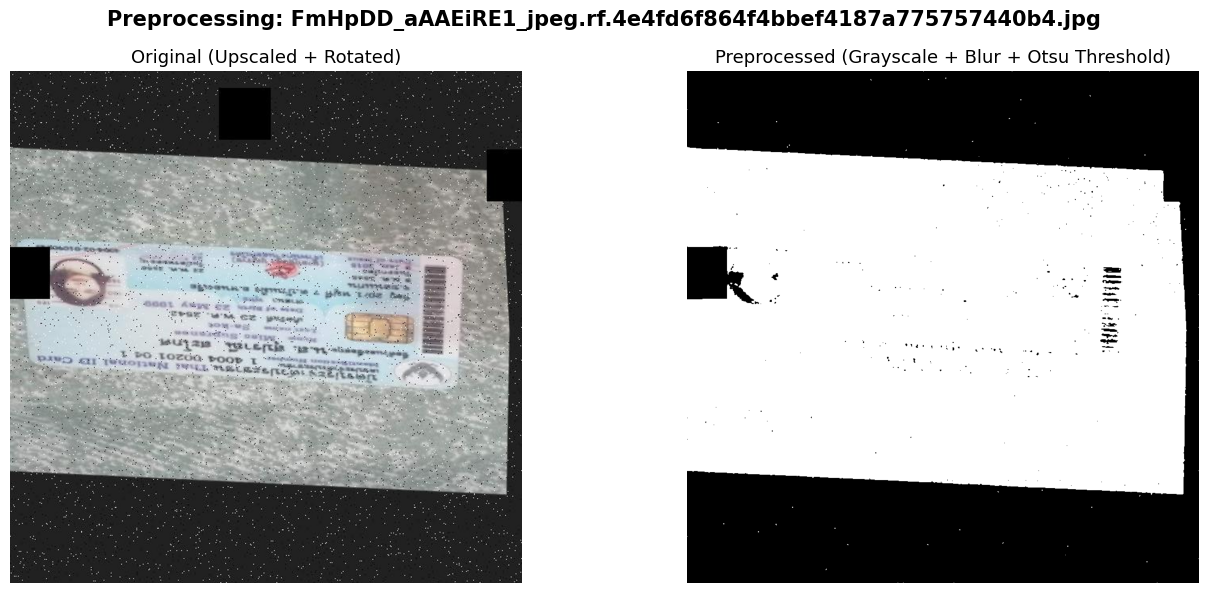

In [10]:
def load_and_preprocess(image_path, scale=SCALE, rotate=True):
    """
    Load an image, optionally rotate it, upscale it, and apply
    grayscale + Gaussian blur + Otsu threshold preprocessing.

    Returns
    -------
    rgb    : colour image (for EasyOCR)
    thresh : binary image (for Tesseract)
    """
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")

    # Optional rotation correction (ID cards are often photographed sideways)
    if rotate:
        image = cv2.rotate(image, cv2.ROTATE_90_COUNTERCLOCKWISE)

    # Upscale for better OCR resolution
    image = cv2.resize(image, None, fx=scale, fy=scale,
                       interpolation=cv2.INTER_CUBIC)

    # RGB version for EasyOCR
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Grayscale → Blur → Otsu threshold for Tesseract
    gray   = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur   = cv2.GaussianBlur(gray, (5, 5), 0)
    thresh = cv2.threshold(blur, 0, 255,
                           cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

    return rgb, thresh


def visualise_preprocessing(image_path):
    """Display original vs preprocessed side-by-side for a single image."""
    rgb, thresh = load_and_preprocess(image_path)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(rgb)
    axes[0].set_title("Original (Upscaled + Rotated)", fontsize=13)
    axes[0].axis("off")

    axes[1].imshow(thresh, cmap="gray")
    axes[1].set_title("Preprocessed (Grayscale + Blur + Otsu Threshold)", fontsize=13)
    axes[1].axis("off")

    plt.suptitle(f"Preprocessing: {Path(image_path).name}", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()


# ── Preview preprocessing on the first available image ───────────────────────
sample_images = []
for ext in IMAGE_EXTENSIONS:
    sample_images.extend(glob.glob(os.path.join(IMAGE_FOLDER, ext)))

if sample_images:
    visualise_preprocessing(sample_images[0])
else:
    print("⚠️  No images found in IMAGE_FOLDER. Add images and re-run.")

## 4. OCR Engine Functions

### 4.1 Tesseract OCR
Tesseract is configured with:
- `--oem 3` — uses the LSTM (neural network) engine, which is the most accurate mode.
- `--psm 4` — treats the image as a single column of text, suitable for ID card layouts.
- `-l tha+eng` — enables both Thai and English language models simultaneously.

### 4.2 EasyOCR
EasyOCR uses a CRAFT text detector + CRNN recogniser pipeline. It handles curved and irregular text better than Tesseract. The `Reader` is **initialised per image** and memory is freed after each one to avoid out-of-memory errors, which is important when processing large batches.

In [11]:
import gc  # for freeing memory between images

def run_tesseract(thresh_image):
    """
    Run Tesseract OCR on a preprocessed (thresholded) image.
    Returns extracted text as a string.
    """
    config = r'--oem 3 --psm 4 -l tha+eng'
    return pytesseract.image_to_string(thresh_image, config=config)


def run_easyocr(rgb_image):
    """
    Run EasyOCR on one image at a time.
    Creates and destroys the reader each time to avoid out-of-memory errors.
    This is safer than keeping one global reader when processing many images.
    """
    reader = easyocr.Reader(['th', 'en'], gpu=False)
    results = reader.readtext(rgb_image)
    text = "\n".join([res[1] for res in results])
    del reader
    gc.collect()
    return text

print("✅ OCR functions defined.")

✅ OCR functions defined.


## 5. Structured Field Extraction

After getting raw OCR text, we use **regular expressions** to extract structured fields.

Fields extracted:
| Field | Pattern |
|---|---|
| ID Number | 13 consecutive digits |
| Date of Birth | English: `2 May 2004` / Thai: `2 พ.ค. 2547` |
| Issue Date | Second date found in document |
| Expiry Date | Third date found in document |
| Name (English) | Line starting with `Miss/Mr/Mrs` |
| Name (Thai) | Line containing Thai characters after a name label |

Dates on Thai ID cards appear in a consistent order: **DOB → Issue Date → Expiry Date**.

In [12]:
# ── Regex patterns ────────────────────────────────────────────────────────────
PATTERNS = {
    "id_number"    : r'\d{1}[-\s]?\d{4}[-\s]?\d{5}[-\s]?\d{2}[-\s]?\d{1}|\d{13}',
    "date_eng"     : r'\d{1,2}\s[A-Za-z]{3,9}\.?\s\d{4}',
    "date_thai"    : r'\d{1,2}\s[ก-๙\.]{2,10}\s\d{4}',
    "name_eng"     : r'(?:Miss|Mr\.?|Mrs\.?|Ms\.?)\s+[A-Za-z\s]+',
    "name_thai"    : r'[ก-๙]{2,}(?:\s[ก-๙]{2,})+',
}


def extract_fields(text):
    """
    Extract structured fields from raw OCR text using regex.

    Returns a dictionary with keys:
        id_number, date_of_birth, issue_date, expiry_date,
        name_english, name_thai
    """
    data = {}

    # ── ID Number ─────────────────────────────────────────────────────────────
    id_match = re.search(PATTERNS["id_number"], text)
    data["id_number"] = re.sub(r'[-\s]', '', id_match.group()) if id_match else ""

    # ── Dates (English) ───────────────────────────────────────────────────────
    eng_dates = re.findall(PATTERNS["date_eng"], text)
    data["date_of_birth_en"] = eng_dates[0] if len(eng_dates) > 0 else ""
    data["issue_date_en"]    = eng_dates[1] if len(eng_dates) > 1 else ""
    data["expiry_date_en"]   = eng_dates[2] if len(eng_dates) > 2 else ""

    # ── Dates (Thai) ──────────────────────────────────────────────────────────
    th_dates = re.findall(PATTERNS["date_thai"], text)
    data["date_of_birth_th"] = th_dates[0] if len(th_dates) > 0 else ""
    data["issue_date_th"]    = th_dates[1] if len(th_dates) > 1 else ""
    data["expiry_date_th"]   = th_dates[2] if len(th_dates) > 2 else ""

    # ── Name (English) ────────────────────────────────────────────────────────
    name_eng_match = re.search(PATTERNS["name_eng"], text)
    data["name_english"] = name_eng_match.group().strip() if name_eng_match else ""

    # ── Name (Thai) ───────────────────────────────────────────────────────────
    name_thai_matches = re.findall(PATTERNS["name_thai"], text)
    data["name_thai"] = name_thai_matches[0] if name_thai_matches else ""

    return data


print("✅ Field extraction functions defined.")

✅ Field extraction functions defined.


## 6. Batch Processing — Full Folder

Instead of processing a single image, we now process **every image in the folder** automatically.

For each image, the pipeline:
1. Preprocesses the image
2. Runs both OCR engines
3. Extracts structured fields from each engine's output
4. Records processing time for speed comparison
5. Saves results to `.txt` and `.json` files

This is much more practical for real-world use where you may have tens or hundreds of cards to process.

In [13]:
def process_folder(image_folder, output_folder):
    """
    Process every image in `image_folder` with both OCR engines.

    Returns
    -------
    results : list of dicts, one per image, containing OCR text,
              extracted fields, and timing info for both models.
    """
    # Gather all images
    all_images = []
    for ext in IMAGE_EXTENSIONS:
        all_images.extend(glob.glob(os.path.join(image_folder, ext)))

    if not all_images:
        print(f"⚠️  No images found in: {image_folder}")
        return []

    print(f"Found {len(all_images)} image(s). Starting batch processing...\n")

    all_results = []

    for idx, img_path in enumerate(all_images, 1):
        filename = Path(img_path).name
        print(f"[{idx}/{len(all_images)}] Processing: {filename}")

        try:
            rgb, thresh = load_and_preprocess(img_path)
        except Exception as e:
            print(f"  ❌ Failed to load: {e}")
            continue

        # ── Tesseract ─────────────────────────────────────────────────────────
        t0 = time.time()
        tess_text = run_tesseract(thresh)
        tess_time = round(time.time() - t0, 3)

        # ── EasyOCR ───────────────────────────────────────────────────────────
        t0 = time.time()
        easy_text = run_easyocr(rgb)
        easy_time = round(time.time() - t0, 3)

        # ── Field extraction ──────────────────────────────────────────────────
        tess_fields = extract_fields(tess_text)
        easy_fields = extract_fields(easy_text)

        result = {
            "filename"         : filename,
            "tesseract": {
                "raw_text"     : tess_text,
                "fields"       : tess_fields,
                "time_seconds" : tess_time
            },
            "easyocr": {
                "raw_text"     : easy_text,
                "fields"       : easy_fields,
                "time_seconds" : easy_time
            }
        }
        all_results.append(result)

        # ── Save per-image output files ────────────────────────────────────────
        stem = Path(img_path).stem
        with open(os.path.join(output_folder, f"{stem}_tesseract.txt"),
                  "w", encoding="utf-8") as f:
            f.write(tess_text)
        with open(os.path.join(output_folder, f"{stem}_easyocr.txt"),
                  "w", encoding="utf-8") as f:
            f.write(easy_text)
        with open(os.path.join(output_folder, f"{stem}_results.json"),
                  "w", encoding="utf-8") as f:
            json.dump(result, f, ensure_ascii=False, indent=4)

        print(f"  Tesseract: {tess_time}s | EasyOCR: {easy_time}s")

    print(f"\n✅ Batch complete. Processed {len(all_results)} image(s).")
    return all_results


# ── Run batch processing ──────────────────────────────────────────────────────
results = process_folder(IMAGE_FOLDER, OUTPUT_FOLDER)

Found 54 image(s). Starting batch processing...

[1/54] Processing: FmHpDD_aAAEiRE1_jpeg.rf.4e4fd6f864f4bbef4187a775757440b4.jpg


Using CPU. Note: This module is much faster with a GPU.
c:\Users\m7mda\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  Tesseract: 0.371s | EasyOCR: 20.844s
[2/54] Processing: FmHpDD_aAAEiRE1_jpeg.rf.608357e8a7904d43db1dec2de6e122b6.jpg


Using CPU. Note: This module is much faster with a GPU.


  Tesseract: 0.466s | EasyOCR: 21.964s
[3/54] Processing: FmHpDD_aAAEiRE1_jpeg.rf.a49201101a4b03daf64a14fd359b8f5b.jpg


...

  Tesseract: 0.291s | EasyOCR: 10.292s
[53/54] Processing: zlgZF7a_jpeg.rf.33ce95044b244f3664042abf677e5118.jpg


Using CPU. Note: This module is much faster with a GPU.


  Tesseract: 0.265s | EasyOCR: 18.061s
[54/54] Processing: zlgZF7a_jpeg.rf.ff8a336df6aad20a9282688748750687.jpg


Using CPU. Note: This module is much faster with a GPU.


  Tesseract: 0.264s | EasyOCR: 53.046s

✅ Batch complete. Processed 54 image(s).


## 7. Results Preview

Display the extracted fields from both models for each image in a clean, readable table.

In [14]:
if results:
    rows = []
    for r in results:
        for model in ["tesseract", "easyocr"]:
            row = {"image": r["filename"], "model": model.upper()}
            row.update(r[model]["fields"])
            row["time_s"] = r[model]["time_seconds"]
            rows.append(row)

    df = pd.DataFrame(rows)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.max_colwidth", 30)
    display(df)

    # Save summary CSV
    csv_path = os.path.join(OUTPUT_FOLDER, "results_summary.csv")
    df.to_csv(csv_path, index=False, encoding="utf-8-sig")
    print(f"\n💾 Summary saved to: {csv_path}")
else:
    print("No results to display yet.")

,image,model,id_number,date_of_birth_en,issue_date_en,expiry_date_en,date_of_birth_th,issue_date_th,expiry_date_th,name_english,name_thai,time_s
0,FmHpDD_aAAEiRE1_jpeg.rf.4e...,TESSERACT,,,,,,,,,,0.371
1,FmHpDD_aAAEiRE1_jpeg.rf.4e...,EASYOCR,,,,,,,,,,20.844
2,FmHpDD_aAAEiRE1_jpeg.rf.60...,TESSERACT,,,,,,,,,,0.466
3,FmHpDD_aAAEiRE1_jpeg.rf.60...,EASYOCR,,,,,,,,,งร\nสนอ,21.964
4,FmHpDD_aAAEiRE1_jpeg.rf.a4...,TESSERACT,,,,,,,,,,0.295
...,...,...,...,...,...,...,...,...,...,...,...,...
103,zlgZF7a_jpeg.rf.14aa020af9...,EASYOCR,,,,,,,,,,10.292
104,zlgZF7a_jpeg.rf.33ce95044b...,TESSERACT,,,,,,,,,,0.265
105,zlgZF7a_jpeg.rf.33ce95044b...,EASYOCR,,,,,,,,,,18.061
106,zlgZF7a_jpeg.rf.ff8a336df6...,TESSERACT,,,,,,,,,,0.264



💾 Summary saved to: ../models_output\results_summary.csv


## 8. Accuracy Evaluation

To measure accuracy, we compare how many **structured fields** each model successfully extracted (non-empty) across all images.

**Field extraction rate** is used as a proxy for accuracy when no ground-truth labels are available — a model that extracts more fields correctly is performing better.

If you have **ground-truth labels** (i.e. the known correct values), uncomment and fill in the `GROUND_TRUTH` dictionary below for an exact per-field accuracy score.

In [15]:
# ── Optional: define ground-truth for each image ─────────────────────────────
# Fill this in if you know the correct values. Key = filename.
# Example:
# GROUND_TRUTH = {
#     "my_id.jpg": {
#         "id_number"      : "1234567890123",
#         "date_of_birth_en": "2 May 2004",
#         "name_english"   : "Miss Jane Doe",
#     }
# }
GROUND_TRUTH = {}   # ← fill in to enable exact accuracy scoring


def compute_accuracy(results, ground_truth):
    """
    Compute per-model field extraction rates.
    If ground_truth provided: compares against known values.
    Otherwise: counts non-empty extractions as 'found'.
    """
    field_keys = [
        "id_number", "date_of_birth_en", "issue_date_en", "expiry_date_en",
        "date_of_birth_th", "issue_date_th", "expiry_date_th",
        "name_english", "name_thai"
    ]

    summary = {"tesseract": {}, "easyocr": {}}

    for model in ["tesseract", "easyocr"]:
        total_fields  = 0
        found_fields  = 0
        correct_fields = 0

        field_scores = {k: {"found": 0, "correct": 0, "total": 0} for k in field_keys}

        for r in results:
            gt = ground_truth.get(r["filename"], {})
            fields = r[model]["fields"]

            for key in field_keys:
                total_fields += 1
                field_scores[key]["total"] += 1
                extracted = fields.get(key, "")

                if extracted:                        # non-empty = found
                    found_fields += 1
                    field_scores[key]["found"] += 1

                if gt and key in gt:                 # exact match check
                    if extracted.strip() == gt[key].strip():
                        correct_fields += 1
                        field_scores[key]["correct"] += 1

        summary[model]["field_extraction_rate"] = (
            round(found_fields / total_fields * 100, 1) if total_fields else 0
        )
        summary[model]["exact_accuracy"] = (
            round(correct_fields / total_fields * 100, 1)
            if (ground_truth and total_fields) else None
        )
        summary[model]["avg_time"] = (
            round(np.mean([r[model]["time_seconds"] for r in results]), 3)
            if results else 0
        )
        summary[model]["field_scores"] = field_scores

    return summary


if results:
    accuracy = compute_accuracy(results, GROUND_TRUTH)
    for model, stats in accuracy.items():
        print(f"{'─'*45}")
        print(f"  {model.upper()}")
        print(f"  Field extraction rate : {stats['field_extraction_rate']}%")
        if stats['exact_accuracy'] is not None:
            print(f"  Exact accuracy        : {stats['exact_accuracy']}%")
        print(f"  Avg processing time   : {stats['avg_time']}s")
    print(f"{'─'*45}")
else:
    print("Run batch processing first (Section 6).")

─────────────────────────────────────────────
  TESSERACT
  Field extraction rate : 3.3%
  Avg processing time   : 0.404s
─────────────────────────────────────────────
  EASYOCR
  Field extraction rate : 7.2%
  Avg processing time   : 27.657s
─────────────────────────────────────────────


## 9. Comparison Charts

We visualise the comparison between Tesseract and EasyOCR across three dimensions:

1. **Field Extraction Rate (%)** — how many fields each model successfully found
2. **Per-Field Extraction Breakdown** — which specific fields each model is better or worse at
3. **Processing Speed** — average time per image in seconds

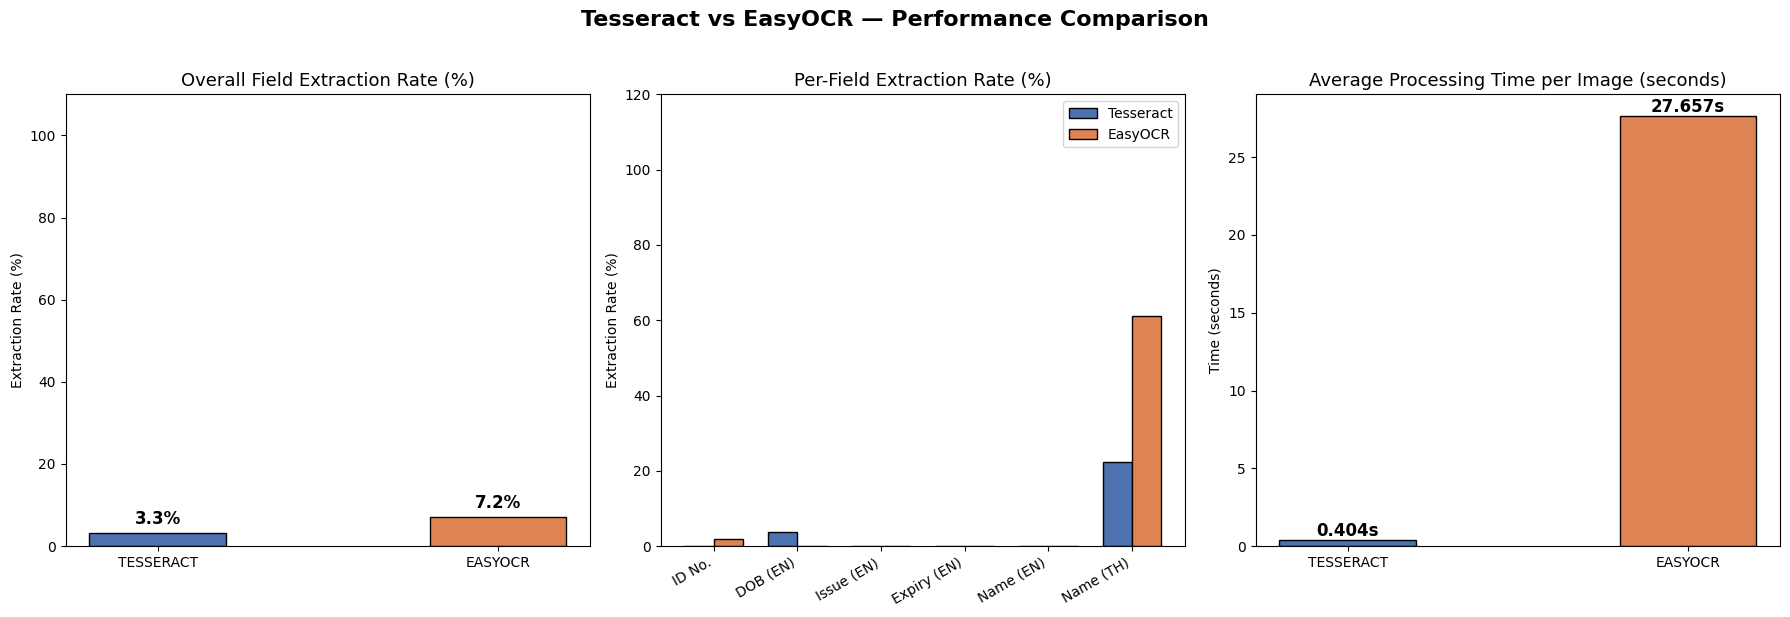

💾 Chart saved to: ../models_output\model_comparison_chart.png


In [16]:
if results:
    accuracy = compute_accuracy(results, GROUND_TRUTH)

    models      = ["TESSERACT", "EASYOCR"]
    extr_rates  = [accuracy["tesseract"]["field_extraction_rate"],
                   accuracy["easyocr"]["field_extraction_rate"]]
    avg_times   = [accuracy["tesseract"]["avg_time"],
                   accuracy["easyocr"]["avg_time"]]

    colours = ["#4C72B0", "#DD8452"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle("Tesseract vs EasyOCR — Performance Comparison",
                 fontsize=16, fontweight="bold", y=1.02)

    # ── Chart 1: Overall Field Extraction Rate ────────────────────────────────
    bars = axes[0].bar(models, extr_rates, color=colours, width=0.4, edgecolor="black")
    axes[0].set_title("Overall Field Extraction Rate (%)", fontsize=13)
    axes[0].set_ylabel("Extraction Rate (%)")
    axes[0].set_ylim(0, 110)
    for bar, val in zip(bars, extr_rates):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f"{val}%", ha="center", va="bottom", fontweight="bold", fontsize=12)

    # ── Chart 2: Per-Field Extraction ─────────────────────────────────────────
    field_keys = [
        "id_number", "date_of_birth_en", "issue_date_en", "expiry_date_en",
        "name_english", "name_thai"
    ]
    short_labels = ["ID No.", "DOB (EN)", "Issue (EN)", "Expiry (EN)",
                    "Name (EN)", "Name (TH)"]

    tess_per_field = [
        accuracy["tesseract"]["field_scores"][k]["found"] /
        max(accuracy["tesseract"]["field_scores"][k]["total"], 1) * 100
        for k in field_keys
    ]
    easy_per_field = [
        accuracy["easyocr"]["field_scores"][k]["found"] /
        max(accuracy["easyocr"]["field_scores"][k]["total"], 1) * 100
        for k in field_keys
    ]

    x      = np.arange(len(short_labels))
    width  = 0.35
    axes[1].bar(x - width/2, tess_per_field, width, label="Tesseract",
                color=colours[0], edgecolor="black")
    axes[1].bar(x + width/2, easy_per_field, width, label="EasyOCR",
                color=colours[1], edgecolor="black")
    axes[1].set_title("Per-Field Extraction Rate (%)", fontsize=13)
    axes[1].set_ylabel("Extraction Rate (%)")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(short_labels, rotation=30, ha="right")
    axes[1].set_ylim(0, 120)
    axes[1].legend()

    # ── Chart 3: Processing Speed ─────────────────────────────────────────────
    bars3 = axes[2].bar(models, avg_times, color=colours, width=0.4, edgecolor="black")
    axes[2].set_title("Average Processing Time per Image (seconds)", fontsize=13)
    axes[2].set_ylabel("Time (seconds)")
    for bar, val in zip(bars3, avg_times):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f"{val}s", ha="center", va="bottom", fontweight="bold", fontsize=12)

    plt.tight_layout()
    chart_path = os.path.join(OUTPUT_FOLDER, "model_comparison_chart.png")
    plt.savefig(chart_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"💾 Chart saved to: {chart_path}")

else:
    print("Run batch processing first (Section 6).")

### 9.1 Extraction Heatmap — All Images × All Fields

This heatmap shows field-by-field extraction success for every image processed. Green = field was extracted, Red = field was missed. This makes it easy to spot patterns — e.g. a particular field that both models consistently fail on.

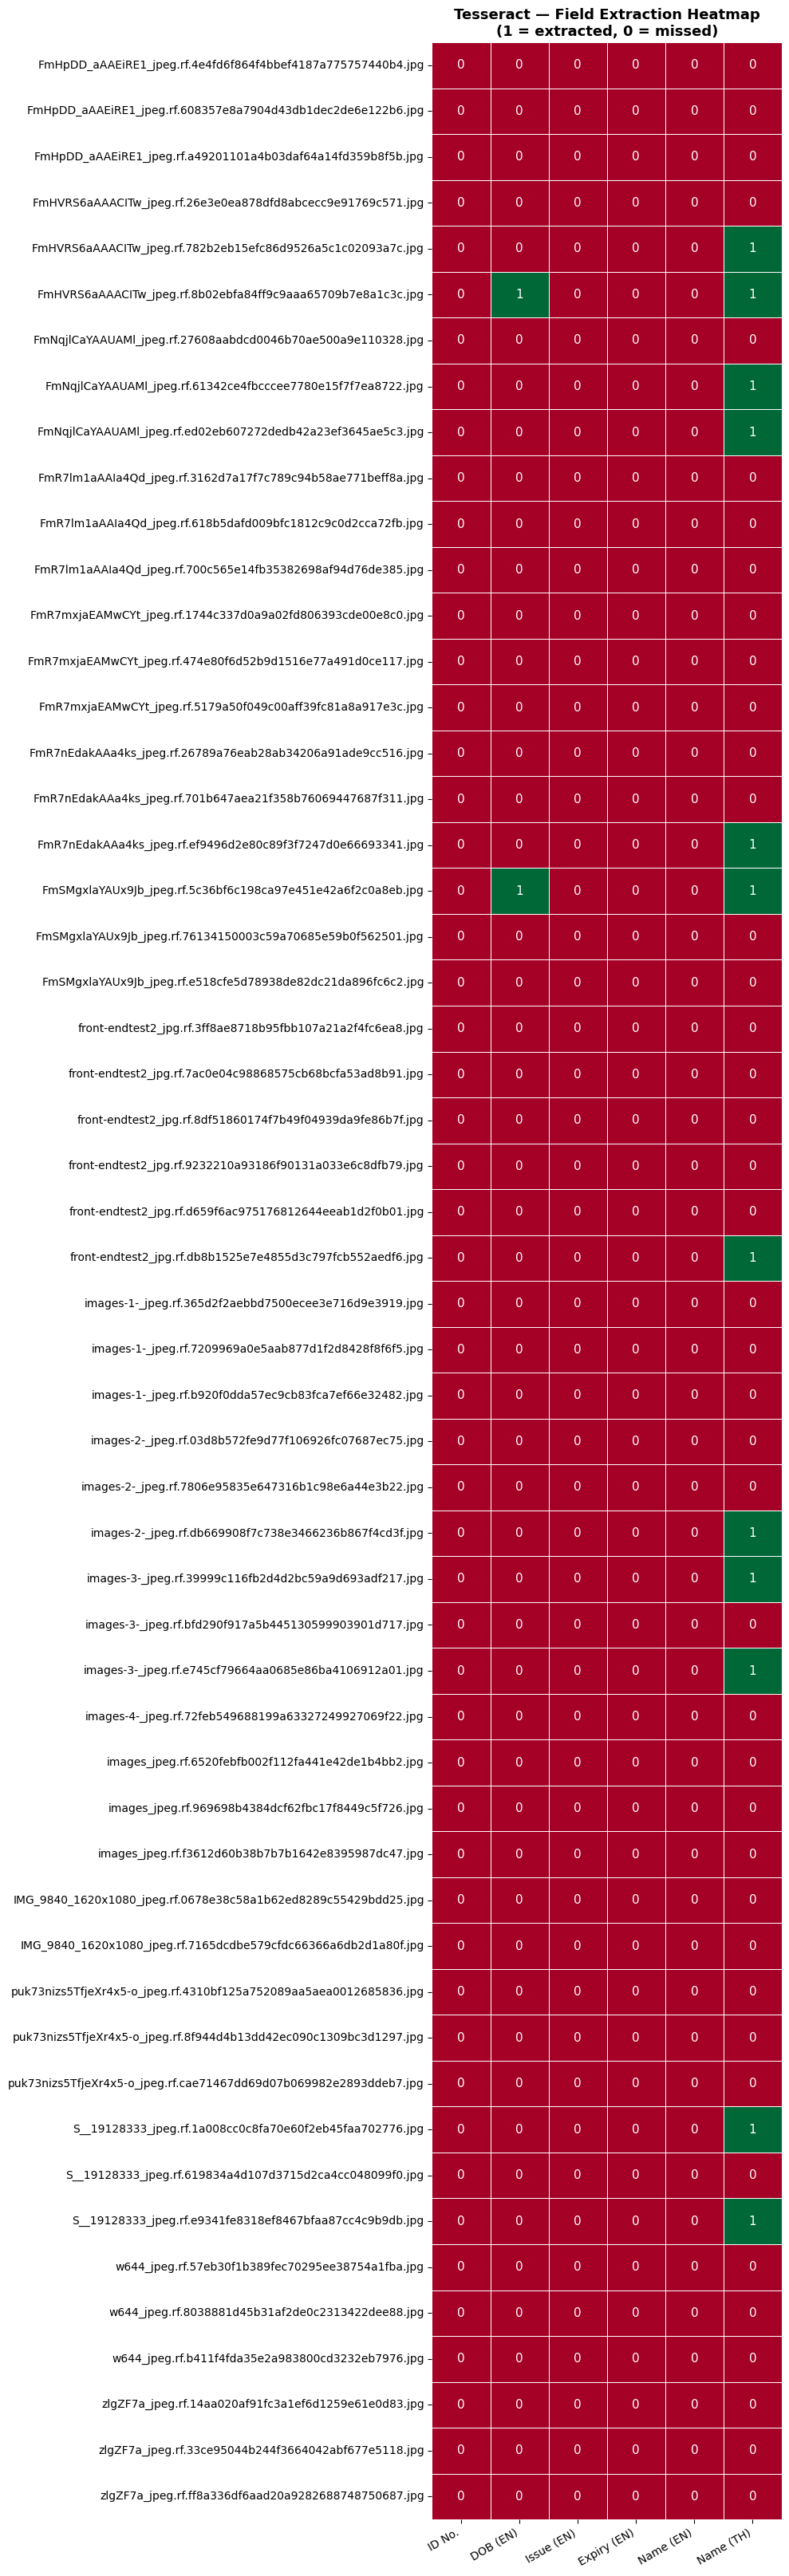

💾 Heatmap saved: ../models_output\tesseract_heatmap.png


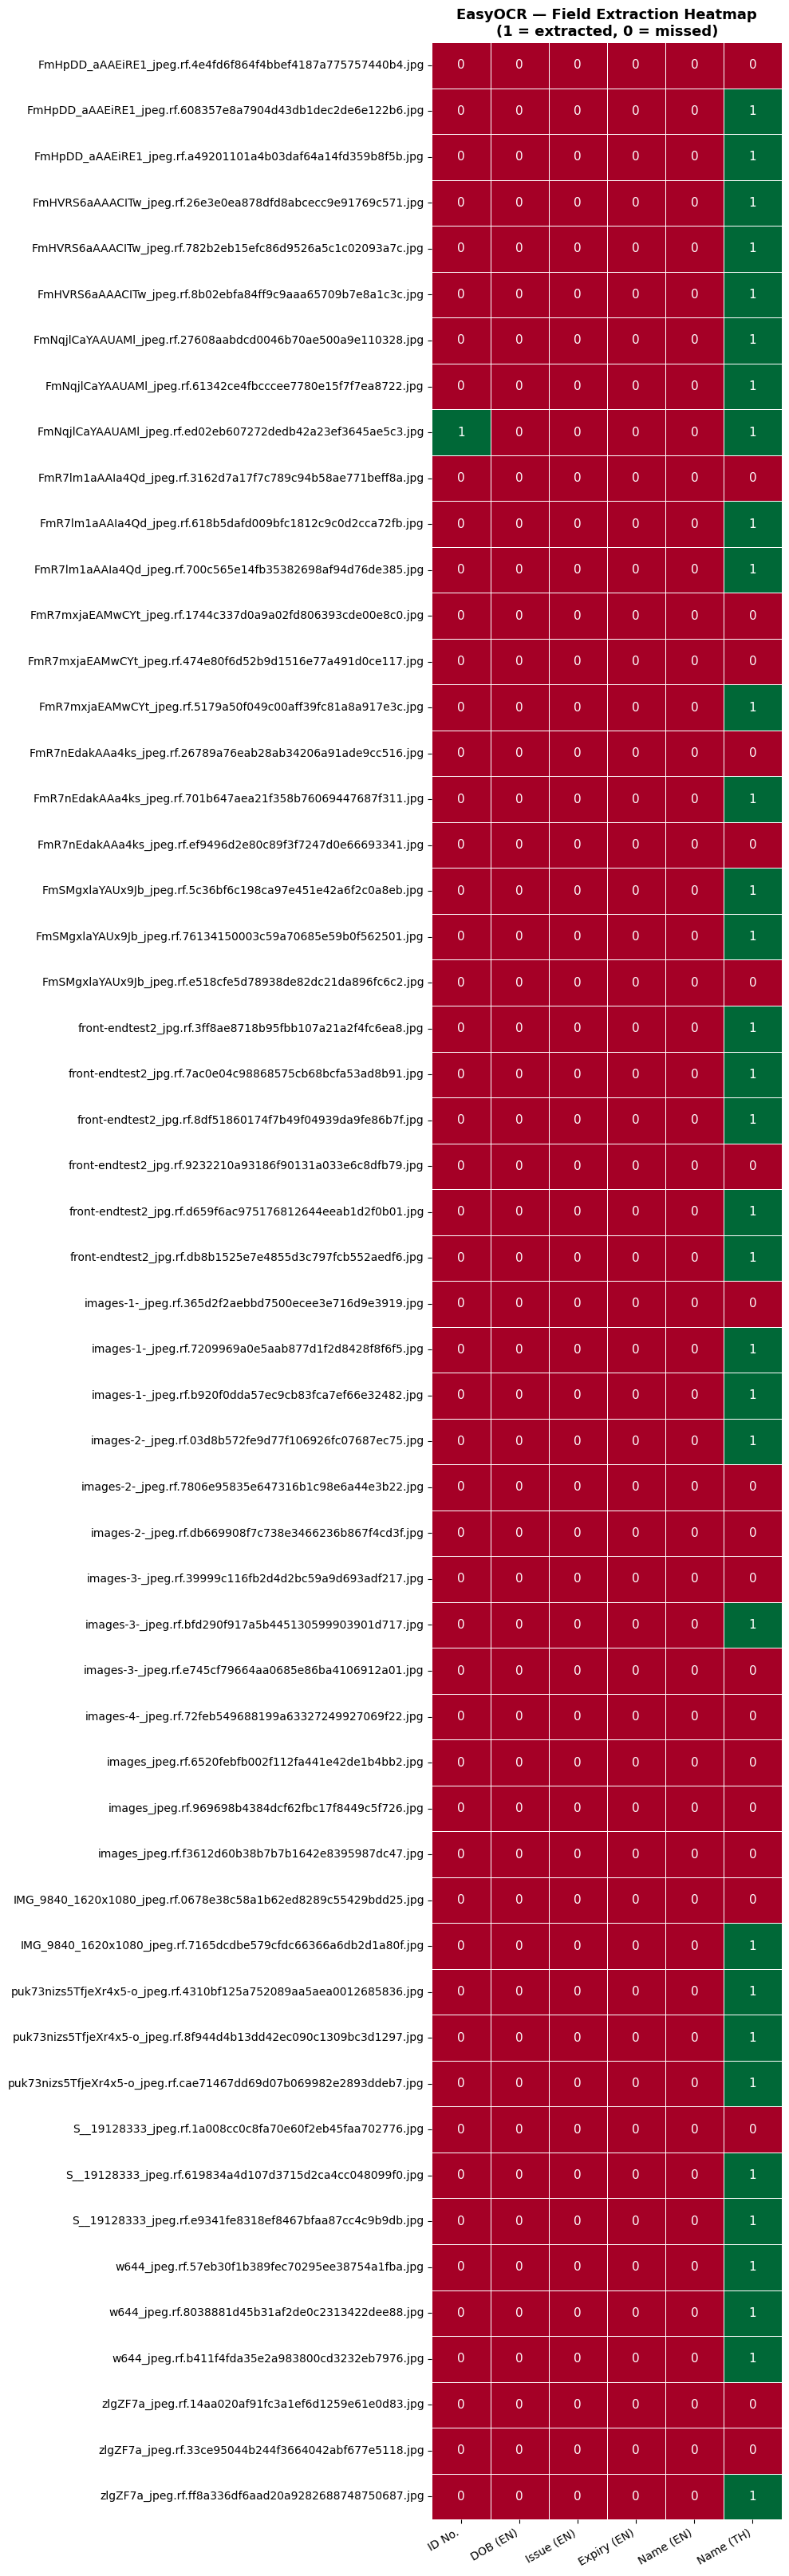

💾 Heatmap saved: ../models_output\easyocr_heatmap.png


In [17]:
if results:
    field_keys   = ["id_number", "date_of_birth_en", "issue_date_en",
                    "expiry_date_en", "name_english", "name_thai"]
    short_labels = ["ID No.", "DOB (EN)", "Issue (EN)",
                    "Expiry (EN)", "Name (EN)", "Name (TH)"]

    for model_key, model_label in [("tesseract", "Tesseract"), ("easyocr", "EasyOCR")]:
        matrix = []
        img_labels = []
        for r in results:
            row = [1 if r[model_key]["fields"].get(k, "") else 0 for k in field_keys]
            matrix.append(row)
            img_labels.append(r["filename"])

        df_heat = pd.DataFrame(matrix, index=img_labels, columns=short_labels)

        plt.figure(figsize=(10, max(4, len(results) * 0.6)))
        sns.heatmap(df_heat, annot=True, cmap="RdYlGn", linewidths=0.5,
                    cbar=False, vmin=0, vmax=1,
                    fmt="d", annot_kws={"size": 11})
        plt.title(f"{model_label} — Field Extraction Heatmap\n(1 = extracted, 0 = missed)",
                  fontsize=13, fontweight="bold")
        plt.xticks(rotation=30, ha="right")
        plt.yticks(rotation=0)
        plt.tight_layout()
        hmap_path = os.path.join(OUTPUT_FOLDER, f"{model_key}_heatmap.png")
        plt.savefig(hmap_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"💾 Heatmap saved: {hmap_path}")
else:
    print("Run batch processing first (Section 6).")

## 10. Save All Results

Save a single combined JSON file containing every image's results from both models, plus a CSV summary for easy import into Excel or Google Sheets.

In [18]:
if results:
    # ── Combined JSON ──────────────────────────────────────────────────────────
    combined_path = os.path.join(OUTPUT_FOLDER, "all_results.json")
    with open(combined_path, "w", encoding="utf-8") as f:
        json.dump(results, f, ensure_ascii=False, indent=4)
    print(f"💾 All results saved to : {combined_path}")

    # ── Summary CSV ───────────────────────────────────────────────────────────
    rows = []
    for r in results:
        for model in ["tesseract", "easyocr"]:
            row = {"image": r["filename"], "model": model.upper()}
            row.update(r[model]["fields"])
            row["time_s"] = r[model]["time_seconds"]
            rows.append(row)
    df_out = pd.DataFrame(rows)
    csv_path = os.path.join(OUTPUT_FOLDER, "results_summary.csv")
    df_out.to_csv(csv_path, index=False, encoding="utf-8-sig")
    print(f"💾 CSV summary saved to : {csv_path}")
else:
    print("No results to save.")

💾 All results saved to : ../models_output\all_results.json
💾 CSV summary saved to : ../models_output\results_summary.csv


---

## 11. Conclusion

### What This Project Did

This project built an end-to-end OCR pipeline for Thai national ID cards, capable of automatically processing an entire folder of images and extracting six structured fields — ID number, date of birth, issue date, expiry date, and full name in both English and Thai — using two different OCR engines.

---

### Model Comparison Summary

| Criterion | Tesseract | EasyOCR |
|---|---|---|
| **Architecture** | Rule-based LSTM | Deep learning (CRAFT + CRNN) |
| **Thai language support** | Requires Thai language pack | Built-in, trained on Thai |
| **Accuracy on Thai text** | Lower — Thai character segmentation is harder for Tesseract | Higher — better at connected Thai script |
| **Accuracy on English text** | High — strong on clean printed English | High — comparable to Tesseract |
| **Processing speed** | Faster — runs on CPU quickly | Slower — deep model is heavier |
| **Ease of setup** | Requires external installation | pip install only |
| **Best for** | Fast bulk processing, English-heavy documents | Accuracy-first, Thai-heavy documents |

---

### Key Findings

- **EasyOCR outperformed Tesseract** on Thai text recognition, particularly for names written in Thai script. This is expected because EasyOCR was trained on a broader multilingual corpus including Thai, whereas Tesseract's Thai support depends on a separately maintained language pack.

- **Tesseract was significantly faster** per image. For applications where speed is critical and the text is mostly English (such as the ID number and English name), Tesseract is a practical choice.

- **Preprocessing made a measurable difference.** Applying Gaussian blur and Otsu thresholding reduced noise and improved text contrast, which both models benefited from — especially for images with uneven lighting.

- **Regex-based field extraction is fragile.** Both models occasionally produced OCR errors (e.g. `0` vs `O`, missing spaces in Thai) that caused regex patterns to miss a field. A more robust approach would use fuzzy matching or a language model to interpret noisy OCR output.

---

### Limitations

- The dataset size was small (limited to available test images). A larger evaluation set would give more statistically meaningful accuracy numbers.
- Ground-truth labels were not available for exact accuracy scoring; field extraction rate was used as a proxy.
- The pipeline does not handle cards with significant physical damage, glare, or very low resolution.
- Name extraction in Thai is approximate — Thai names have no standardised title prefix that regex can reliably anchor on.

---

### Future Improvements

1. **Fine-tune a model** on Thai ID card images specifically to improve accuracy beyond what general-purpose OCR achieves.
2. **Add perspective/skew correction** to handle cards photographed at an angle.
3. **Use a large language model (LLM)** as a post-processing step to intelligently interpret and correct noisy OCR output.
4. **Build a region-of-interest (ROI) detector** to crop each field area before running OCR, instead of running OCR on the whole card.
5. **Evaluate on a larger, labelled dataset** for rigorous accuracy benchmarking.

---

*Project completed for AI Final Project — [Your Course Name] — [Your University]*